<a href="https://colab.research.google.com/github/Devadeth-cmyk/Fake_or_Real/blob/main/fake_or_real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries


In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
import pandas as pd
import numpy as np
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#Read dataset
we have to concatenate 2 csv file (fake and true)

In [62]:
df_fake = pd.read_csv('/content/drive/MyDrive/AI ML/Datasets/Fake.csv')
display(df_fake.head())

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [63]:
df_true = pd.read_csv('/content/drive/MyDrive/AI ML/Datasets/True.csv')
display(df_true.head())

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [64]:
df_true["label"] = 1
df_fake["label"] = 0

In [65]:
# Concatenating 2 files
df = pd.concat([df_true, df_fake], ignore_index=True)


In [66]:
df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


# EDA

In [67]:
df_fake.head(5)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [68]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB


In [69]:
df.shape

(44898, 5)

In [70]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB


In [71]:
df_true.size

107085

In [72]:
df_fake.size

117405

In [73]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [74]:
#Checking for missing value
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


##Preprocessing

In [75]:
# Create a separate DataFrame for the cleaned text output
df_clean_text = df.copy()

### Duplicate Removal

In [76]:
# Checking duplicates
df.duplicated().sum()

np.int64(209)

In [77]:
# Removing duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df_clean_text = df.copy()


In [78]:
df.duplicated().sum()

np.int64(0)

### Punctuation Removal

In [79]:
#Removing punctutions
def remove_punc(text):
  text = str(text)
  text = text.replace("�", "")
  punctuationless_text = ''.join(i for i in text if i not in string.punctuation)
  return punctuationless_text

In [80]:
df["punctuationless_text"] = [remove_punc(text) for text in df["text"]]

In [81]:
df

,title,text,subject,date,label,punctuationless_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1,WASHINGTON Reuters Trump campaign adviser Geo...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1,SEATTLEWASHINGTON Reuters President Donald Tr...
...,...,...,...,...,...,...
44684,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0,21st Century Wire says As 21WIRE reported earl...
44685,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0,21st Century Wire says It s a familiar theme W...
44686,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0,Patrick Henningsen 21st Century WireRemember ...
44687,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0,21st Century Wire says Al Jazeera America will...


### Lowercasing

In [82]:
df["lowercased"] = [text.lower() for text in df["punctuationless_text"]]  #Lowercasing the tokens

In [83]:
df.head(3)

,title,text,subject,date,label,punctuationless_text,lowercased
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...,washington reuters the head of a conservative...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...,washington reuters transgender people will be...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...,washington reuters the special counsel invest...


### Tokenization

In [84]:
# we convert the entire text into a list of unique words.
def tokenization(text): #Function for tokenization
  word_list = nltk.word_tokenize(text)
  return word_list


In [85]:
df["tokenized"] = [tokenization(text) for text in df["lowercased"]]

In [86]:
df.head(3)

,title,text,subject,date,label,punctuationless_text,lowercased,tokenized
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...,washington reuters the head of a conservative...,"[washington, reuters, the, head, of, a, conser..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...,washington reuters transgender people will be...,"[washington, reuters, transgender, people, wil..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...,washington reuters the special counsel invest...,"[washington, reuters, the, special, counsel, i..."


### Stop words removal

In [87]:
# Remove stop words
stop_words_list = nltk.corpus.stopwords.words('english')
stop_words_list
def remove_stopwords(tokens):
  stop_word_less_list = [i for i in tokens if i not in stop_words_list]
  return stop_word_less_list

In [88]:
df["stop_words_removed"] = [remove_stopwords(text) for text in df["tokenized"]]

In [89]:
df.head(3)

,title,text,subject,date,label,punctuationless_text,lowercased,tokenized,stop_words_removed
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...,washington reuters the head of a conservative...,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...,washington reuters transgender people will be...,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...,washington reuters the special counsel invest...,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest..."


### Lemmatization

In [90]:
lem_obj = WordNetLemmatizer()
def lemmatizing(stem_token_list):
  lem_list = [lem_obj.lemmatize(word) for word in stem_token_list ]
  return lem_list

In [91]:
df["lemmatized_text"] = [lemmatizing(text) for text in df["stop_words_removed"]]

In [92]:
df.head(3)

,title,text,subject,date,label,punctuationless_text,lowercased,tokenized,stop_words_removed,lemmatized_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The head of a conservative...,washington reuters the head of a conservative...,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu...","[washington, reuters, head, conservative, repu..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,WASHINGTON Reuters Transgender people will be...,washington reuters transgender people will be...,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all...","[washington, reuters, transgender, people, all..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,WASHINGTON Reuters The special counsel invest...,washington reuters the special counsel invest...,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest...","[washington, reuters, special, counsel, invest..."


In [93]:
df_clean_text['text'] = df['lemmatized_text'].apply(lambda x: ' '.join(x))

In [94]:
df_clean_text.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",washington reuters head conservative republica...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,washington reuters transgender people allowed ...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,washington reuters special counsel investigati...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,washington reuters trump campaign adviser geor...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,seattlewashington reuters president donald tru...,politicsNews,"December 29, 2017",1


# Embedding

## TF-IDF

In [95]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Ensure the cleaned text is a string
df['text'] = df['text'].fillna('').astype(str)

print("Number of text samples:", len(df))


Number of text samples: 44689


## Date and Subject Features

### Date column fix

In [96]:
# Convert 'date' to datetime and extract features
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek # Monday=0, Sunday=6

# Drop original 'date' column
df = df.drop(columns=['date'])

display(df[['year', 'month', 'day_of_week']].head())

,year,month,day_of_week
0,2017.0,12.0,6.0
1,2017.0,12.0,4.0
2,2017.0,12.0,6.0
3,2017.0,12.0,5.0
4,2017.0,12.0,4.0


### Implementing one hot encoding on subjet column

In [97]:
# Initialize OneHotEncoder for the subject feature.
# It will be fitted only on the training data to avoid data leakage.
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    # Compatibility with older scikit-learn versions
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)

### Combining all features

In [98]:
numeric_features = df[['year', 'month', 'day_of_week']].fillna(0).astype(float)

# Keep subject as a DataFrame so the encoder can be fitted after the train/test split.
subject_features = df[['subject']].fillna('Unknown').astype(str)

print("Numeric feature shape:", numeric_features.shape)
print("Subject feature shape:", subject_features.shape)


Numeric feature shape: (44689, 3)
Subject feature shape: (44689, 1)


## Data Splitting

In [99]:
y = df['label'].astype(int) #Target

#First splitting rows into indics to prevent data leakage
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Splitting data to train and test
X_text_train = df.iloc[train_idx]['text']
X_text_test = df.iloc[test_idx]['text']

X_tfidf_train = tfidf_vectorizer.fit_transform(X_text_train)
X_tfidf_test = tfidf_vectorizer.transform(X_text_test)

# Subject features: fit only on training subjects
X_subject_train = ohe.fit_transform(subject_features.iloc[train_idx])
X_subject_test = ohe.transform(subject_features.iloc[test_idx])

# Date features
X_date_train = csr_matrix(numeric_features.iloc[train_idx].values)
X_date_test = csr_matrix(numeric_features.iloc[test_idx].values)

# Combine TF-IDF + date + subject features
X_train = hstack([X_tfidf_train, X_date_train, X_subject_train]).tocsr()
X_test = hstack([X_tfidf_test, X_date_test, X_subject_test]).tocsr()

y_train = y.iloc[train_idx].to_numpy()
y_test = y.iloc[test_idx].to_numpy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (35751, 5011)
X_test shape: (8938, 5011)
y_train shape: (35751,)
y_test shape: (8938,)


## Model Training and Evaluation

### Logistic Regression

In [100]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



### Decision Tree

In [101]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Initialize and train the Decision Tree model
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_dec_tree = dec_tree_model.predict(X_test)

# Evaluate the model
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dec_tree))



Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



### Neural Network

In [102]:
# Convert sparse matrix to dense for TensorFlow
# A dense representation is required for this neural-network architecture.
X_train_dense = X_train.toarray() if hasattr(X_train, "toarray") else np.asarray(X_train)
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else np.asarray(X_test)

# Build the Neural Network model
nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dense.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the model
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

# Train the model
history = nn_model.fit(
    X_train_dense,
    y_train,
    epochs = 5,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
)

# Evaluate the model
loss, accuracy = nn_model.evaluate(X_test_dense, y_test, verbose=0)
print(f"\nNeural Network Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_nn_proba = nn_model.predict(X_test_dense, verbose=0).ravel()
y_pred_nn = (y_pred_nn_proba >= 0.5).astype(int)

print("\nNeural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │     1,283,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,633 (5.03 MB)

 Trainable params: 1,316,865 (5.02 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/10
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.9994 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 2.4629e-06
Epoch 2/10
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 1.0000 - loss: 5.6281e-05 - val_accuracy: 1.0000 - val_loss: 6.6798e-07
Epoch 3/10
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 1.0000 - loss: 2.1391e-05 - val_accuracy: 1.0000 - val_loss: 3.0641e-07
Epoch 4/10
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 1.0000 - loss: 1.6002e-05 - val_accuracy: 1.0000 - val_loss: 8.4252e-08
Epoch 5/10
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 1.0000 - loss: 1.0326e-05 - val_accuracy: 1.0000 - val_loss: 2.0606e-08
Epoch 6/10
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - accuracy: 1.0000 - loss: 3.2845e-06 - val_accuracy: 1.0000 - val_loss: 1.2942e-08
Epoch 7/10
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 1.0000 - loss: 2.3600e-06 - val_accuracy: 1.0000 - val_loss: 6.7355e-09
Epoch 8/10
1006/1006 ━━━

#Error Analysis and Model Interpretation

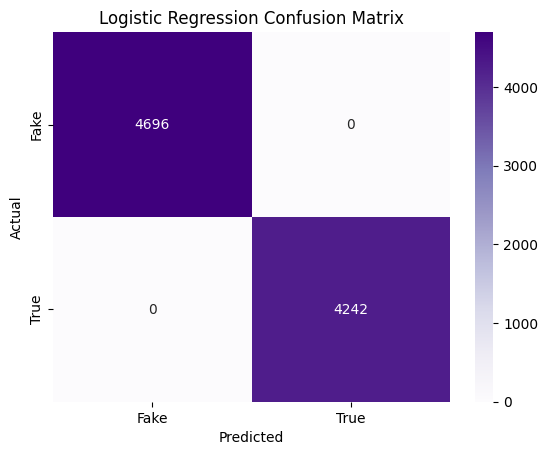

In [103]:
# Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Purples', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

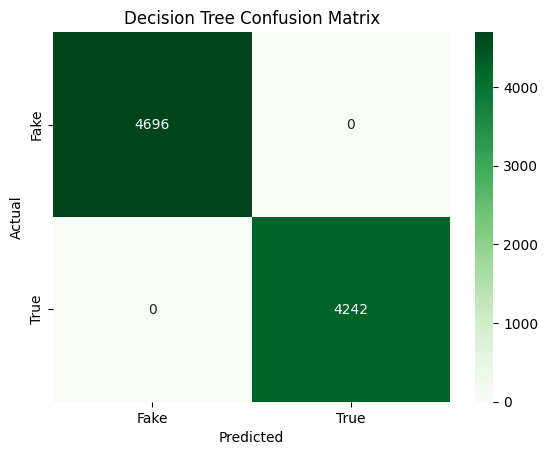

In [104]:
# Confusion Matrix
cm_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
sns.heatmap(cm_dec_tree, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake', 'True'], yticklabels=['Fake', 'True'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

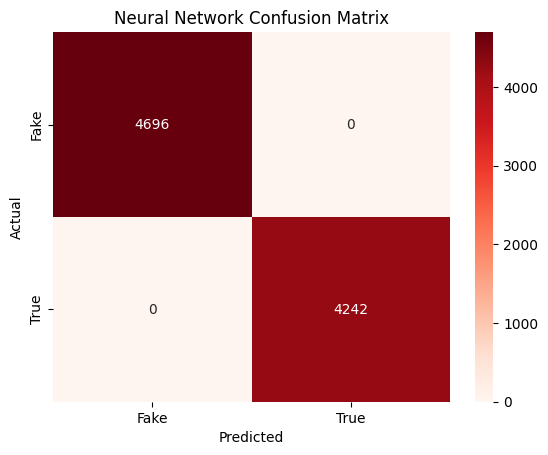

In [105]:
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(
    cm_nn,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Fake', 'True'],
    yticklabels=['Fake', 'True']
)
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#Streamlit deployment

In [106]:
import pickle

In [108]:
#saving the model with the best performance as a .pkl file, here it is adaboost model

with open('decision_model.pkl', 'wb') as file:
  pickle.dump(dec_tree_model, file)

In [111]:
import pickle

# Save the TF-IDF Vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf_vectorizer, file)

# Save the OneHotEncoder
with open('onehot_encoder.pkl', 'wb') as file:
    pickle.dump(ohe, file)

print("TF-IDF vectorizer and OneHotEncoder saved successfully.")

TF-IDF vectorizer and OneHotEncoder saved successfully.


## Streamlit App Files

Here are the files for your Streamlit application:

1.  **`streamlit_app.py`**: Contains the main Python code for your web application.
2.  **`requirements.txt`**: Lists all the Python libraries required for the app to run.
3.  **`Procfile`**: (Optional, for cloud deployment like Heroku) Specifies the command to run the application.

In [109]:
%%writefile streamlit_app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import string
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix
from datetime import datetime

# Ensure NLTK data is available
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except nltk.downloader.DownloadError:
    nltk.download('wordnet')

# Load the trained model and vectorizers
@st.cache_resource
def load_model_and_artifacts():
    with open('decision_model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        tfidf_vectorizer = pickle.load(f)
    with open('onehot_encoder.pkl', 'rb') as f:
        onehot_encoder = pickle.load(f)
    return model, tfidf_vectorizer, onehot_encoder

model, tfidf_vectorizer, onehot_encoder = load_model_and_artifacts()

# Preprocessing functions (from your notebook)
def remove_punc(text):
    text = str(text)
    text = text.replace("", "")
    punctuationless_text = ''.join(i for i in text if i not in string.punctuation)
    return punctuationless_text

def tokenization(text):
    word_list = nltk.word_tokenize(text)
    return word_list

stop_words_list = nltk.corpus.stopwords.words('english')
def remove_stopwords(tokens):
    stop_word_less_list = [i for i in tokens if i not in stop_words_list]
    return stop_word_less_list

lem_obj = WordNetLemmatizer()
def lemmatizing(stem_token_list):
    lem_list = [lem_obj.lemmatize(word) for word in stem_token_list]
    return lem_list

def preprocess_text(text):
    text = remove_punc(text)
    text = text.lower()
    tokens = tokenization(text)
    tokens = remove_stopwords(tokens)
    lemmatized_tokens = lemmatizing(tokens)
    return ' '.join(lemmatized_tokens)

# Streamlit App
st.title('Fake News Detection App')
st.write("Enter a news article's title, text, and subject to predict if it's real or fake.")

news_title = st.text_input('News Title')
news_text = st.text_area('News Text')
news_subject = st.selectbox('News Subject', onehot_encoder.categories_[0]) # Use categories from trained encoder

# Hardcoding date features for simplicity, as the model expects them
# For a more robust app, you might ask for a date input from the user.
current_year = datetime.now().year
current_month = datetime.now().month
current_day_of_week = datetime.now().weekday() # Monday=0, Sunday=6

if st.button('Predict'):
    if not news_text or not news_title:
        st.warning('Please provide both news title and text.')
    else:
        # Preprocess the input text
        processed_combined_text = preprocess_text(news_title + " " + news_text)

        # TF-IDF Vectorization
        text_features = tfidf_vectorizer.transform([processed_combined_text])

        # One-Hot Encoding for Subject
        subject_features = onehot_encoder.transform(pd.DataFrame([news_subject], columns=['subject']))

        # Date Features (matching the training format)
        # Note: These are simplified for the demo. In a real app, you might parse a date from the input.
        date_features = csr_matrix(np.array([[current_year, current_month, current_day_of_week]]))

        # Combine all features
        combined_features = hstack([text_features, date_features, subject_features]).tocsr()

        # Make prediction
        prediction = model.predict(combined_features)

        if prediction[0] == 0:
            st.error('Prediction: This news article is LIKELY FAKE.')
        else:
            st.success('Prediction: This news article is LIKELY REAL.')


Writing streamlit_app.py


In [110]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
nltk
tensorflow # if using NN, otherwise remove
scipy


Writing requirements.txt


## How to Run Your Streamlit App

1.  **Save the files**: Make sure the `streamlit_app.py`, `requirements.txt`, `decision_model.pkl`, `tfidf_vectorizer.pkl`, and `onehot_encoder.pkl` files are in the same directory.

2.  **Install dependencies**: Open your terminal or command prompt, navigate to the directory where you saved the files, and run:
    ```bash
    pip install -r requirements.txt
    ```

3.  **Run the app**: After installation, run the Streamlit app using:
    ```bash
    streamlit run streamlit_app.py
    ```

4.  **Access the app**: Your web browser should automatically open a new tab with your Streamlit application (usually at `http://localhost:8501`).